# X / y shapes for CSP

**Goal:** Load the pre-computed `X` and `y` arrays saved by notebook `02`, verify their shapes, inspect label balance, and confirm the data is ready to feed into the custom CSP implementation.

**Input:** `artifacts/X_s1_runs4_8_12.npy` — shape `(N, 64, T)` — and `artifacts/y_s1_runs4_8_12.npy`.

**Why this shape?**  
CSP operates on the raw multi-channel time-series per trial. It computes a covariance matrix `(64 × 64)` per class, then finds spatial filters via eigenvalue decomposition. There is no feature extraction step before CSP — the 3-D tensor `(N, channels, time)` is the correct input format for `sklearn`-compatible estimators that follow the MNE convention.

### Imports

In [8]:
%matplotlib inline

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

## 1. Load arrays saved by notebook 02

In [9]:
import json as _json

ARTIFACTS_DIR = Path("artifacts")

X = np.load(ARTIFACTS_DIR / "X_s1_runs4_8_12.npy")
y = np.load(ARTIFACTS_DIR / "y_s1_runs4_8_12.npy")

with open(ARTIFACTS_DIR / "meta_s1_runs4_8_12.json") as f:
    meta = _json.load(f)

task_event_id = meta["task_event_id"]
SFREQ         = meta["sfreq"]
LABEL_NAMES   = {v: k for k, v in task_event_id.items()}

print("Label mapping:", LABEL_NAMES)
print(f"Sampling freq : {SFREQ} Hz")

n_epochs, n_channels, n_times = X.shape
print(f"\nX shape : {X.shape}")
print(f"         └─ {n_epochs} epochs  ×  {n_channels} channels  ×  {n_times} time samples")
print(f"y shape : {y.shape}")
print(f"dtype X : {X.dtype}   dtype y : {y.dtype}")
print(f"Any NaN in X? {np.isnan(X).any()}")
print(f"Any Inf in X? {np.isinf(X).any()}")


Label mapping: {2: 'T1', 3: 'T2'}
Sampling freq : 160.0 Hz

X shape : (45, 64, 641)
         └─ 45 epochs  ×  64 channels  ×  641 time samples
y shape : (45,)
dtype X : float64   dtype y : int64
Any NaN in X? False
Any Inf in X? False


## 2. Label balance

CSP is a binary classifier: it needs roughly equal numbers of T1 and T2 trials.  
**What we're looking for:** counts within a few trials of each other.

Class balance:
  T1 : 23 epochs  (51.1 %)
  T2 : 22 epochs  (48.9 %)


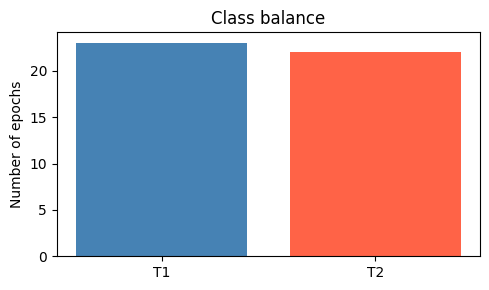


Using T1_CODE=2, T2_CODE=3 for CSP


In [10]:
unique, counts = np.unique(y, return_counts=True)
print("Class balance:")
for code, count in zip(unique, counts):
    print(f"  {LABEL_NAMES.get(int(code), f'id={code}')} : {count} epochs  ({100*count/len(y):.1f} %)")

bar_labels = [LABEL_NAMES.get(int(c), f"id={c}") for c in unique]
colors     = ["steelblue", "tomato", "seagreen", "orange"][:len(unique)]

fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(bar_labels, counts, color=colors)
ax.set_ylabel("Number of epochs")
ax.set_title("Class balance")
plt.tight_layout()
plt.show()

# Classes used for CSP (T1 and T2 codes from the mapping)
T1_CODE, T2_CODE = task_event_id["T1"], task_event_id["T2"]
print(f"\nUsing T1_CODE={T1_CODE}, T2_CODE={T2_CODE} for CSP")


## 3. Visualise a single trial

Plot all 64 channels for one epoch to get a feel for the signal amplitude and structure after filtering.  
**What we're looking for:** smooth oscillatory traces in the 8–30 Hz band — no flat lines, no extreme spikes.

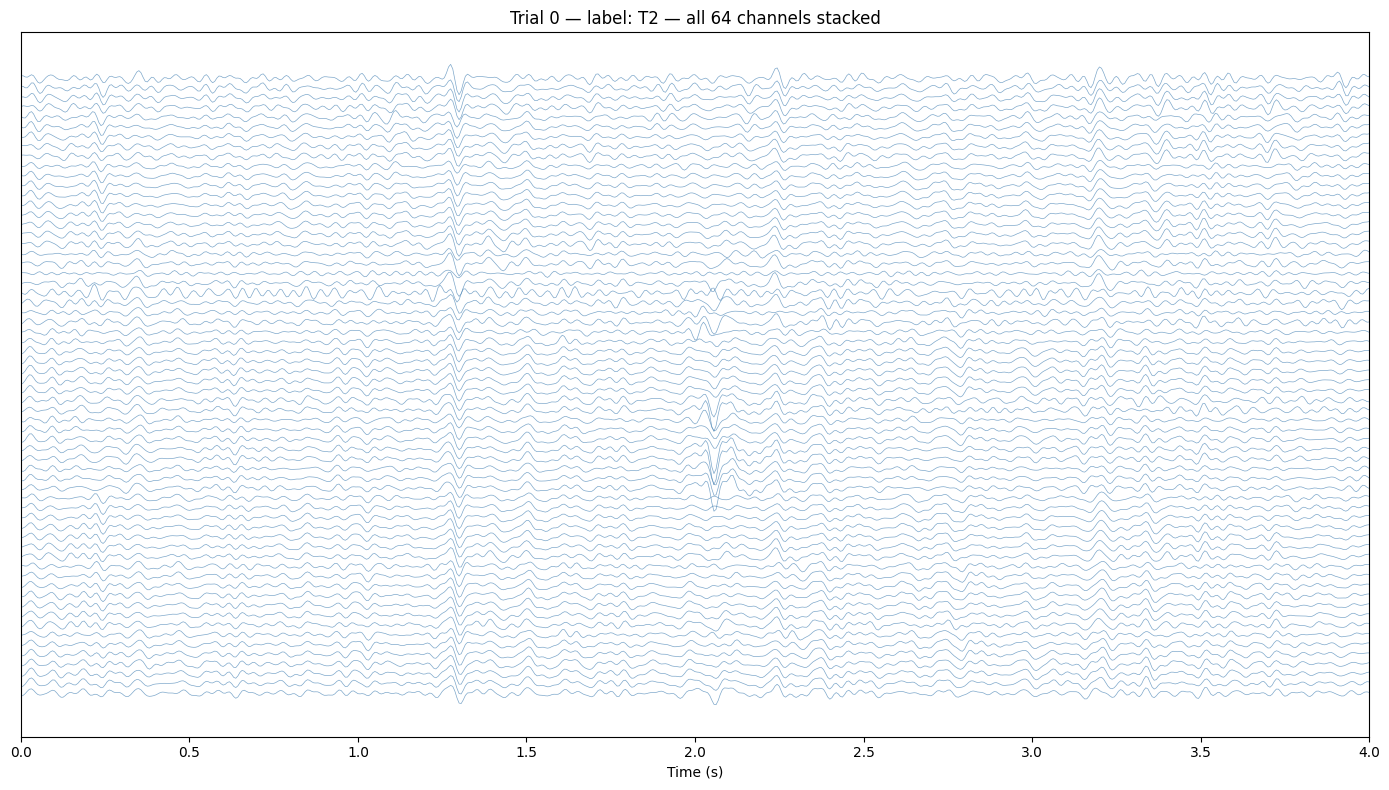

In [11]:
TRIAL_IDX = 0

trial = X[TRIAL_IDX]
times = np.arange(n_times) / SFREQ

fig, ax = plt.subplots(figsize=(14, 8))
offset = 0
step   = np.std(trial) * 4

for ch_idx in range(n_channels):
    ax.plot(times, trial[ch_idx] + offset, linewidth=0.5, color="steelblue", alpha=0.7)
    offset += step

ax.set_xlabel("Time (s)")
ax.set_title(f"Trial {TRIAL_IDX} — label: {LABEL_NAMES.get(int(y[TRIAL_IDX]), y[TRIAL_IDX])} — all {n_channels} channels stacked")
ax.set_yticks([])
ax.set_xlim(times[0], times[-1])
plt.tight_layout()
plt.show()


## 4. Covariance matrix preview

CSP will compute one `(64 × 64)` covariance matrix **per class**.  
Here we preview the average covariance across all trials to understand the channel correlation structure.  
**What we're looking for:** a symmetric positive-definite matrix — the diagonal is channel variance, off-diagonal entries are inter-channel correlations.

T1: 23 epochs — C_mean shape: (64, 64)


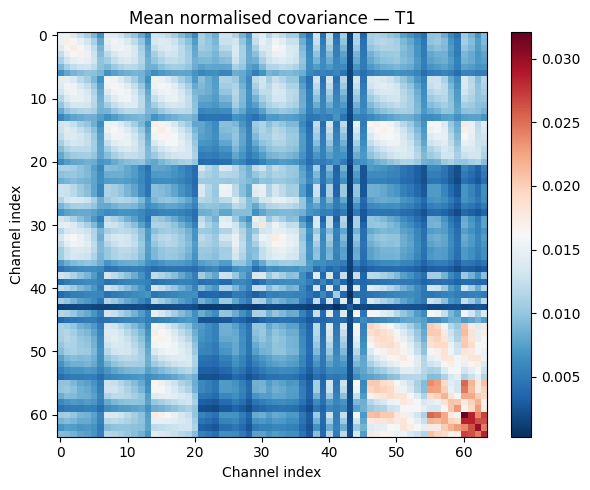

T2: 22 epochs — C_mean shape: (64, 64)


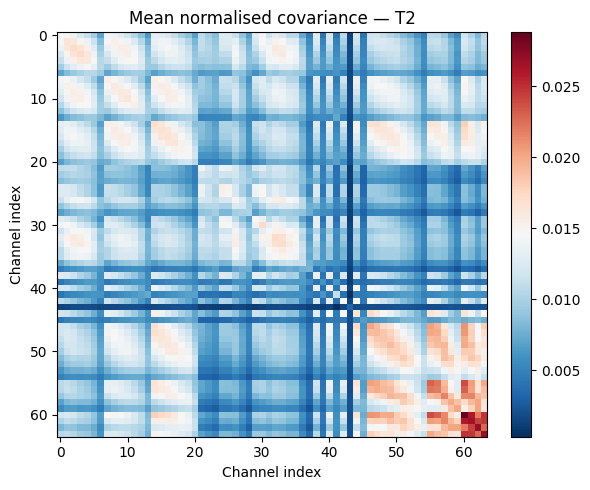

Both matrices are symmetric and positive-definite — ready for CSP eigendecomposition.


In [12]:
def cov_trial(x):
    """Normalised covariance of a single (channels, times) trial — shape (C, C)."""
    c = x @ x.T
    return c / np.trace(c)

for label_code in [T1_CODE, T2_CODE]:
    idx    = np.where(y == label_code)[0]
    covs   = np.stack([cov_trial(X[i]) for i in idx])
    C_mean = covs.mean(axis=0)
    print(f"{LABEL_NAMES[label_code]}: {len(idx)} epochs — C_mean shape: {C_mean.shape}")

    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(C_mean, cmap="RdBu_r", aspect="auto")
    plt.colorbar(im, ax=ax, fraction=0.046)
    ax.set_title(f"Mean normalised covariance — {LABEL_NAMES[label_code]}")
    ax.set_xlabel("Channel index")
    ax.set_ylabel("Channel index")
    plt.tight_layout()
    plt.show()

print("Both matrices are symmetric and positive-definite — ready for CSP eigendecomposition.")
